# pyironflow

https://github.com/BAMresearch/NFDI4IngScientificWorkflowRequirements

## Reload workflow in pyironflow

In [1]:
workflow_json_filename = "workflow.json"

In [2]:
from python_workflow_definition.pyiron_workflow import load_workflow_json

In [3]:
from pyironflow import PyironFlow

In [4]:
wf = load_workflow_json(file_name=workflow_json_filename)
PyironFlow([wf]).gui

![screenshot](screenshot.png)

In [5]:
wf.run()

/home/jan/miniforge3/envs/processing/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


{'compile_paper__compile_paper': '/home/jan/Desktop/visual-programming-with-pyironflow/nfdi/postprocessing/paper.pdf'}

## Define workflow with pyironflow

In [6]:
import os

In [7]:
from workflow import (
    generate_mesh as _generate_mesh, 
    convert_to_xdmf as _convert_to_xdmf,
    poisson as _poisson,
    plot_over_line as _plot_over_line,
    substitute_macros as _substitute_macros,
    compile_paper as _compile_paper,
)

In [8]:
from pyiron_workflow import Workflow, to_function_node

from python_workflow_definition.pyiron_workflow import write_workflow_json

In [9]:
generate_mesh = to_function_node("generate_mesh", _generate_mesh, "generate_mesh")
convert_to_xdmf = to_function_node("convert_to_xdmf", _convert_to_xdmf, "convert_to_xdmf")
poisson = to_function_node("poisson", _poisson, "poisson")
plot_over_line = to_function_node("plot_over_line", _plot_over_line, "plot_over_line")
substitute_macros = to_function_node("substitute_macros", _substitute_macros, "substitute_macros")
compile_paper = to_function_node("compile_paper", _compile_paper, "compile_paper")

In [10]:
wf = Workflow("my_workflow")

In [11]:
wf.domain_size = 2.0

In [12]:
wf.source_directory = os.path.abspath(os.path.join(os.curdir, "source"))

In [13]:
wf.gmsh_output_file = generate_mesh(
    domain_size=wf.domain_size,
    source_directory=wf.source_directory,
)

In [14]:
wf.meshio_output_dict = convert_to_xdmf(
    gmsh_output_file=wf.gmsh_output_file,
)

In [15]:
wf.poisson_dict = poisson(
    meshio_output_xdmf=wf.meshio_output_dict["xdmf_file"], 
    meshio_output_h5=wf.meshio_output_dict["h5_file"],
    source_directory=wf.source_directory,
)

In [16]:
wf.pvbatch_output_file = plot_over_line(
    poisson_output_pvd_file=wf.poisson_dict["pvd_file"], 
    poisson_output_vtu_file=wf.poisson_dict["vtu_file"],
    source_directory=wf.source_directory,
)

In [17]:
wf.macros_tex_file = substitute_macros( 
    pvbatch_output_file=wf.pvbatch_output_file, 
    ndofs=wf.poisson_dict["numdofs"], 
    domain_size=wf.domain_size,
    source_directory=wf.source_directory,
)

In [18]:
wf.paper_output = compile_paper(
    macros_tex=wf.macros_tex_file, 
    plot_file=wf.pvbatch_output_file,
    source_directory=wf.source_directory,
)

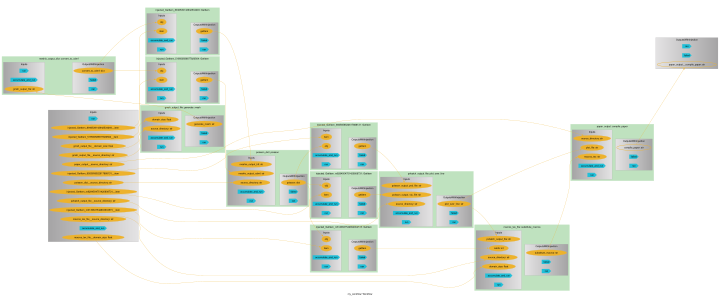

In [19]:
wf.draw(size=(10,10))

In [20]:
write_workflow_json(graph_as_dict=wf.graph_as_dict, file_name=workflow_json_filename)

In [21]:
!cat {workflow_json_filename}

{
  "version": "0.1.0",
  "nodes": [
    {
      "id": 0,
      "type": "function",
      "value": "workflow.generate_mesh"
    },
    {
      "id": 1,
      "type": "function",
      "value": "workflow.convert_to_xdmf"
    },
    {
      "id": 2,
      "type": "function",
      "value": "workflow.poisson"
    },
    {
      "id": 3,
      "type": "function",
      "value": "workflow.plot_over_line"
    },
    {
      "id": 4,
      "type": "function",
      "value": "workflow.substitute_macros"
    },
    {
      "id": 5,
      "type": "function",
      "value": "workflow.compile_paper"
    },
    {
      "id": 6,
      "type": "input",
      "name": "domain_size",
      "value": 2.0
    },
    {
      "id": 7,
      "type": "input",
      "name": "source_directory",
      "value": "/home/jan/Desktop/visual-programming-with-pyironflow/nfdi/source"
    },
    {
      "id": 8,
      "type": "output",
      "name": "result"
    }
  ],
  "edges": [
    {
      "target": 2,
      "targetPo